In [1]:
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from flyvis.task.vel_decoder import VelocityTemporalDecoder, second_diff_loss
from flyvis.network import Network
import flyvis
from utils.setup_environment import *
from utils.Glider1D import Glider1D, CustomStimuli, RenderedData
from utils.glider_utils import *


In [2]:
# ----------------------------
# 1. Network + decoder setup
# ----------------------------
network_view = flyvis.NetworkView(flyvis.results_dir / "flow/0000/000")
network = network_view.init_network()
decoder = VelocityTemporalDecoder(network.connectome)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

network.to(device)
decoder.to(device)

[2025-12-05 13:05:34] network_view:122 Initialized network view at /home/guardomayas/flyvis_data/results/flow/0000/000
[2025-12-05 13:05:34] logging_utils:23 epe not in /home/guardomayas/flyvis_data/results/flow/0000/000/validation, but 'loss' is. Falling back to 'loss'. You can rerun the ensemble validation to make appropriate recordings of the losses.
[2025-12-05 13:05:39] network:222 Initialized network with NumberOfParams(free=734, fixed=2959) parameters.
[2025-12-05 13:05:39] chkpt_utils:36 Recovered network state.
[2025-12-05 13:05:42] vel_decoder:68 Initialized VelocityTemporalDecoder with NumberOfParams(free=193, fixed=0) parameters, kernel_size=21


Using device: cpu


VelocityTemporalDecoder(
  (temp_conv): Conv1d(8, 8, kernel_size=(21,), stride=(1,), padding=(10,), groups=8, bias=False)
  (norm): BatchNorm1d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (linear): Linear(in_features=8, out_features=1, bias=True)
)

In [3]:
# save_path = Path("results/pre_trained_network_decoder.pt")
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# checkpoint = torch.load(save_path, map_location=device)

# network.load_state_dict(checkpoint["network_state_dict"])
# decoder.load_state_dict(checkpoint["decoder_state_dict"])

# train_errors = checkpoint["train_errors"]
# val_errors   = checkpoint["val_errors"]

# network.eval()
# decoder.eval()

## Load Gliders

In [4]:
rules = ['uniform_edge', '2pt', '3pt_Conv', '3pt_Div', 'uncorrelated']
seeds = [1, 20, 30, 55, 65, 48]  
fps = 24
T = fps * 3
dt = 1 / 100
x_resol = 33
vel = 1
k_size = 1

-------- Seed: 1 --------


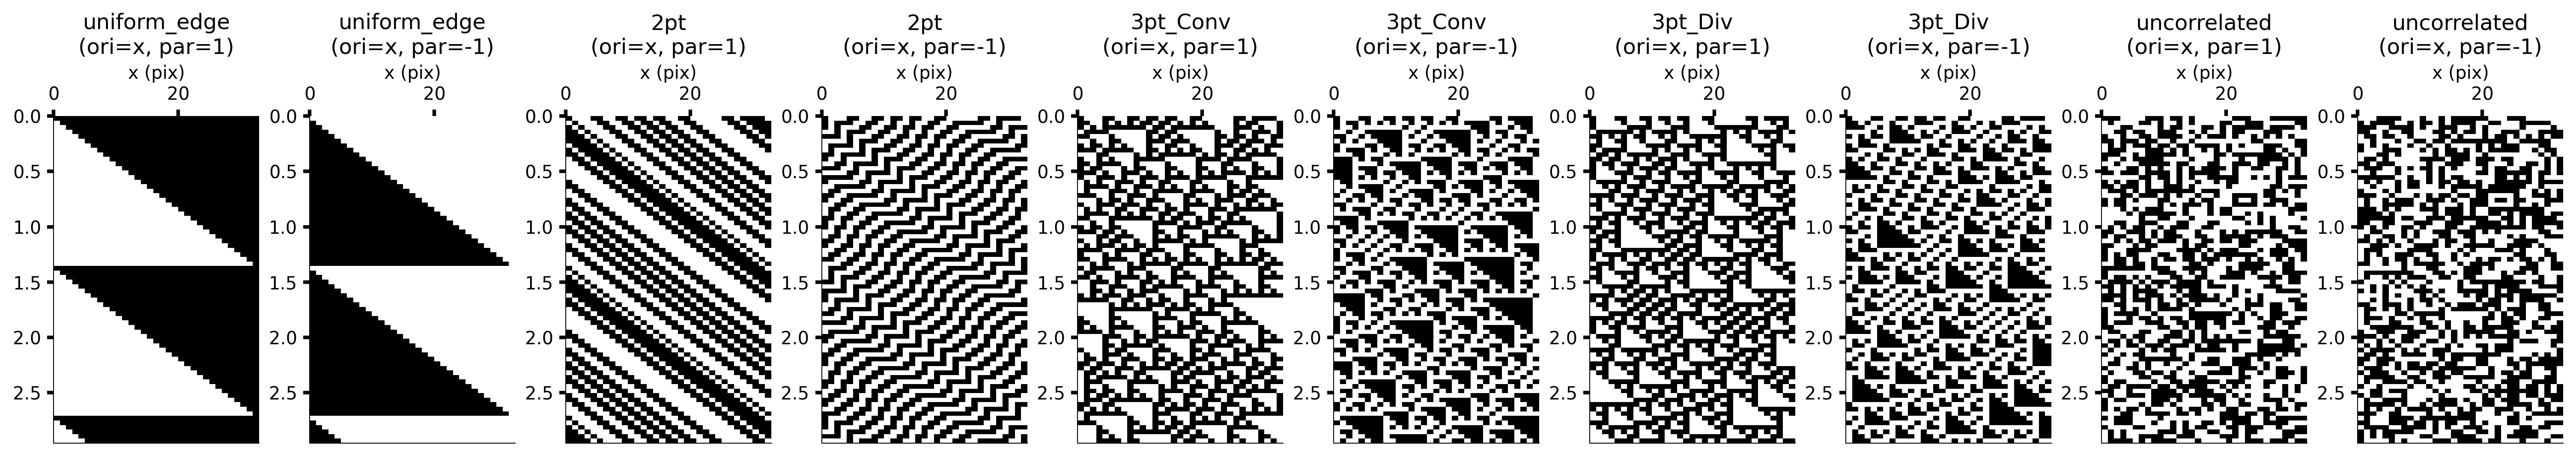

Created movie_input for 20 sequences, shape = torch.Size([20, 300, 1, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 20 --------


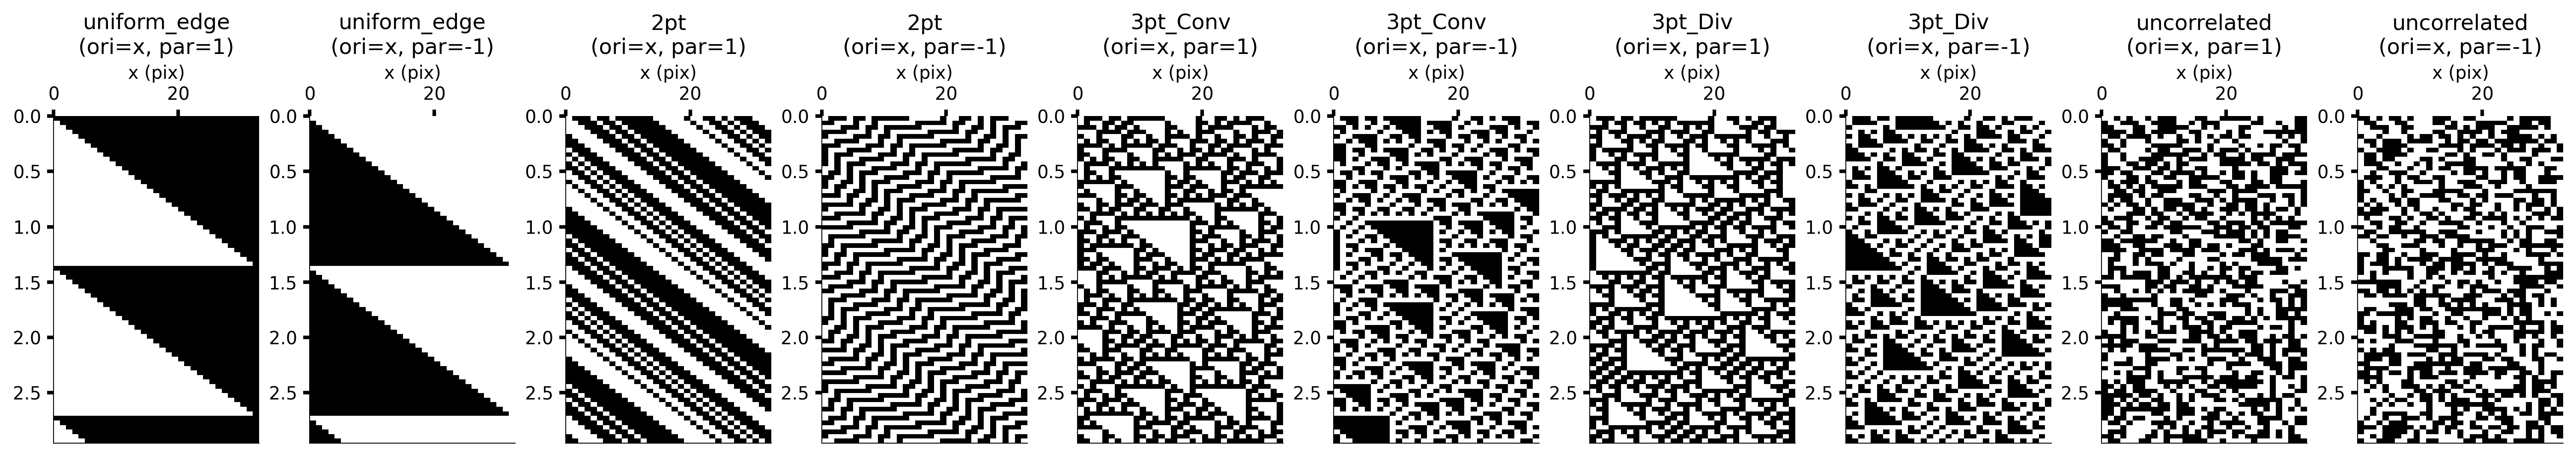

Created movie_input for 20 sequences, shape = torch.Size([20, 300, 1, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 30 --------


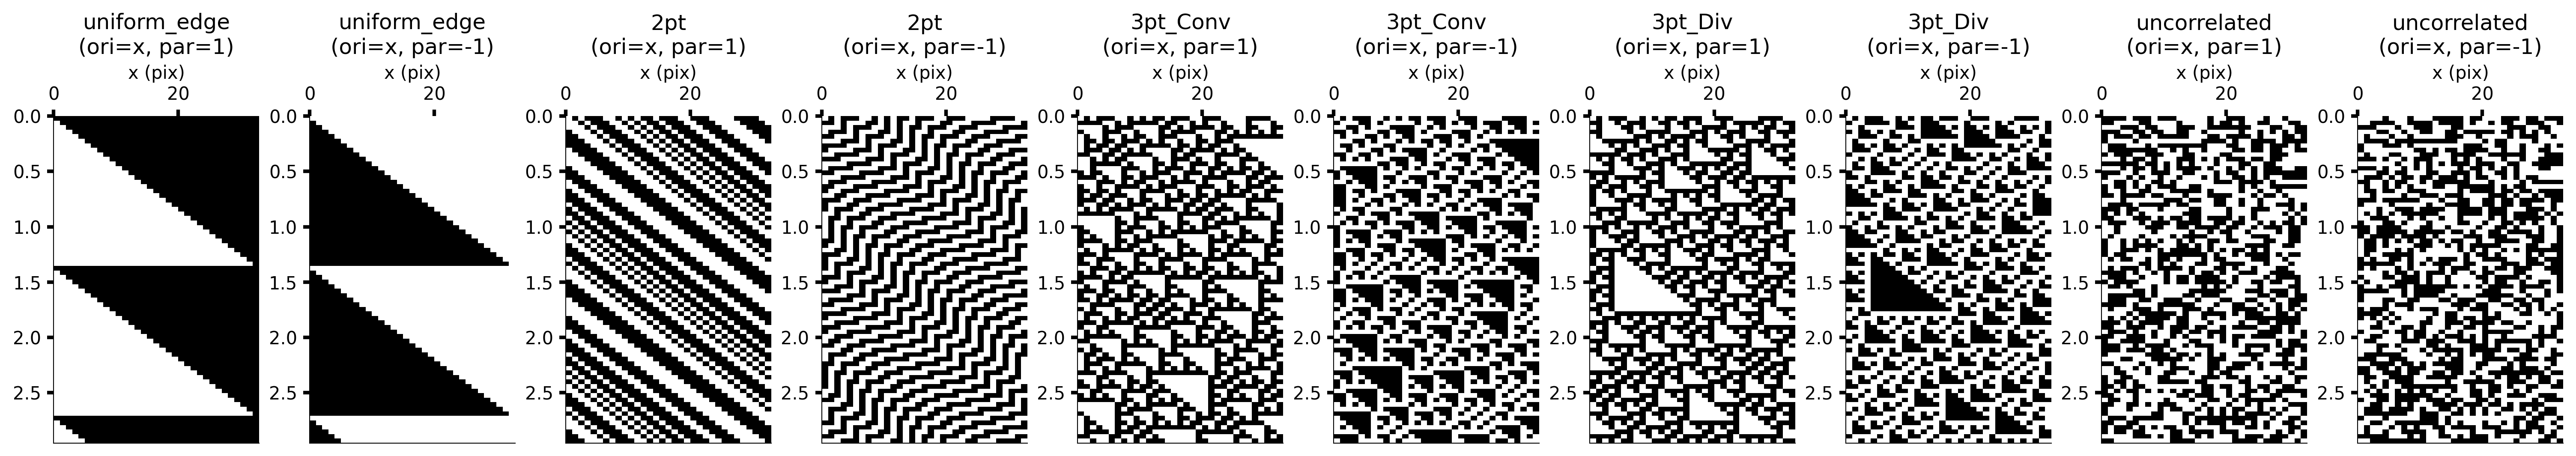

Created movie_input for 20 sequences, shape = torch.Size([20, 300, 1, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 55 --------


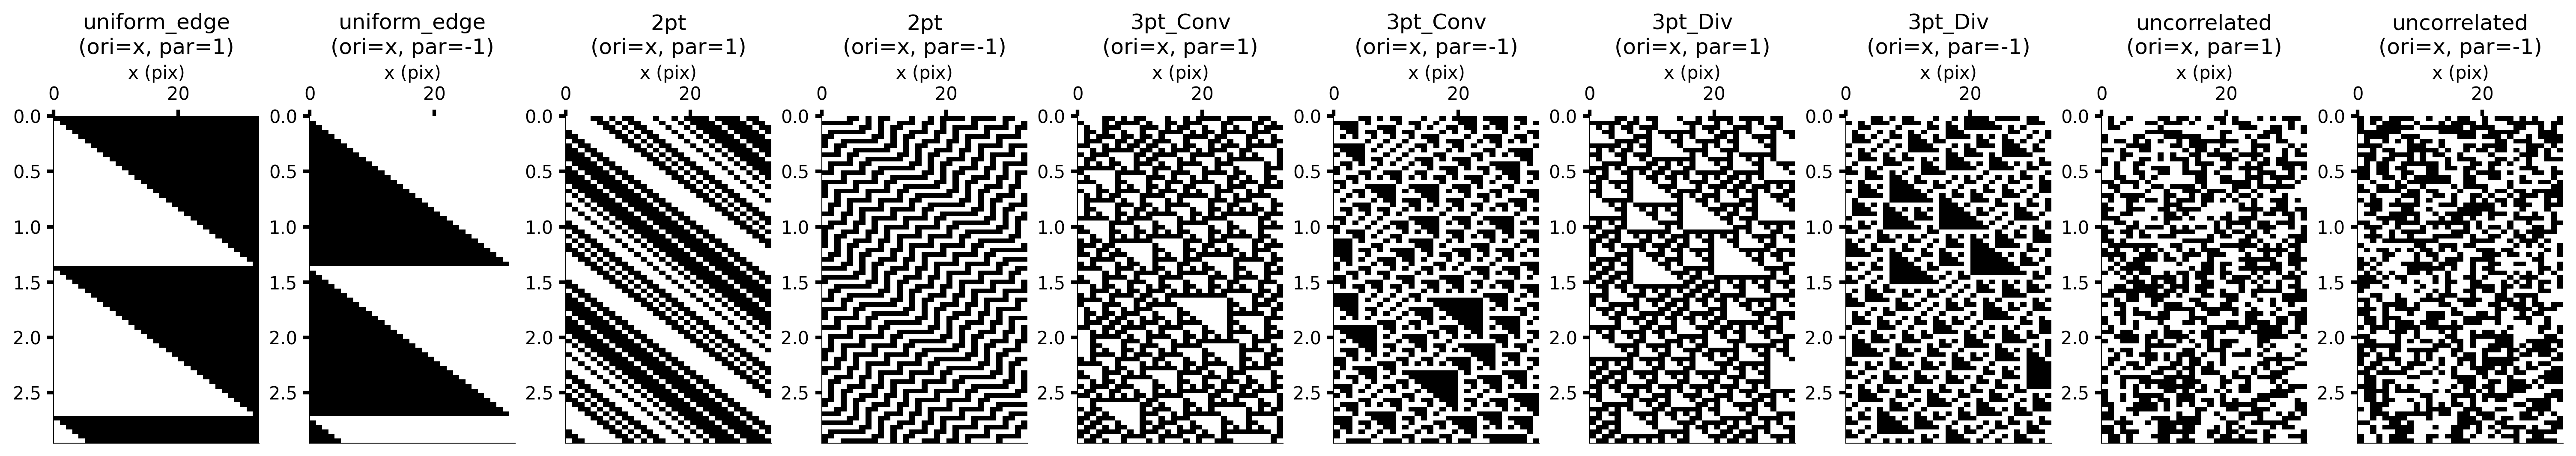

Created movie_input for 20 sequences, shape = torch.Size([20, 300, 1, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 65 --------


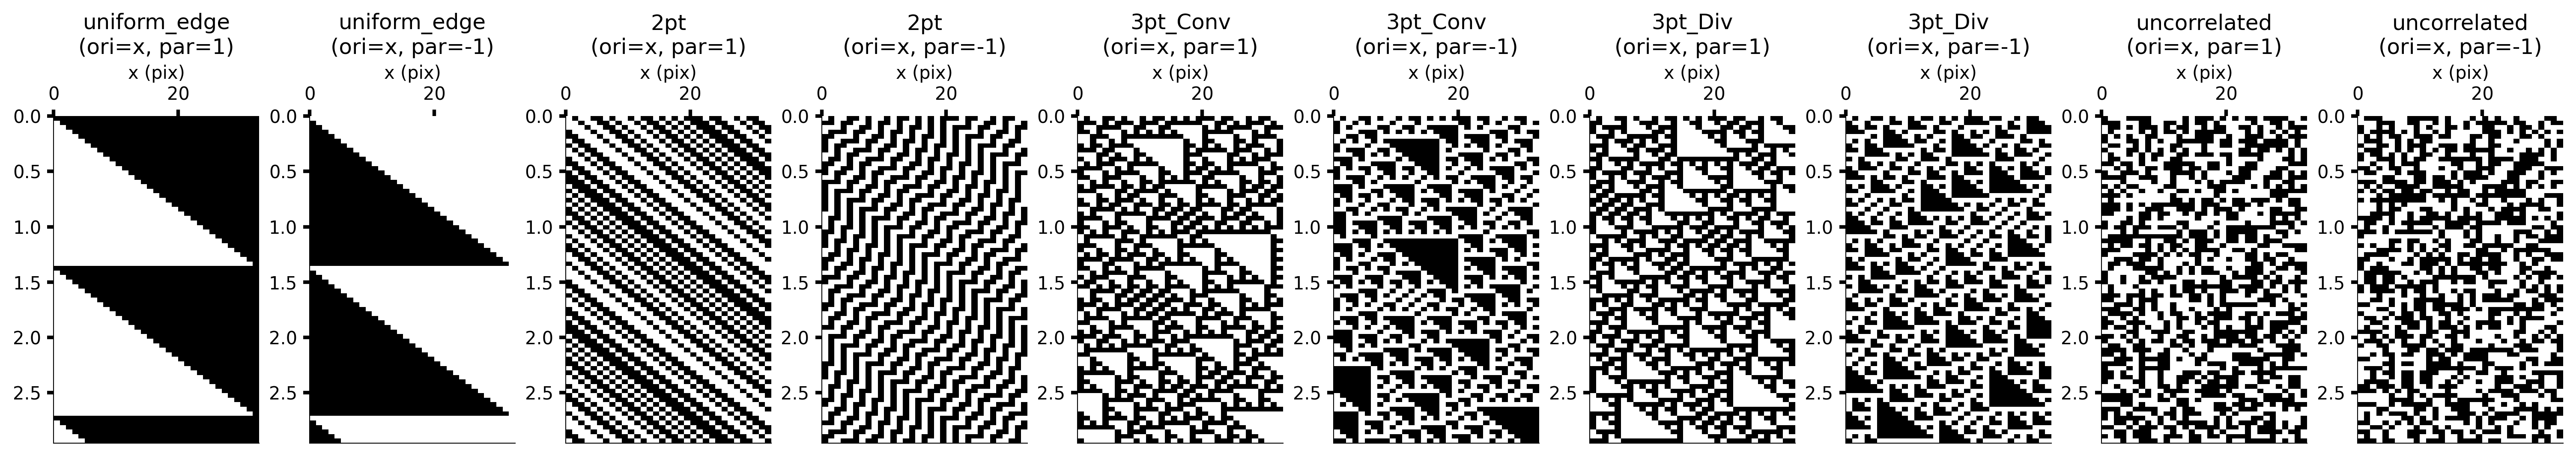

Created movie_input for 20 sequences, shape = torch.Size([20, 300, 1, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])
-------- Seed: 48 --------


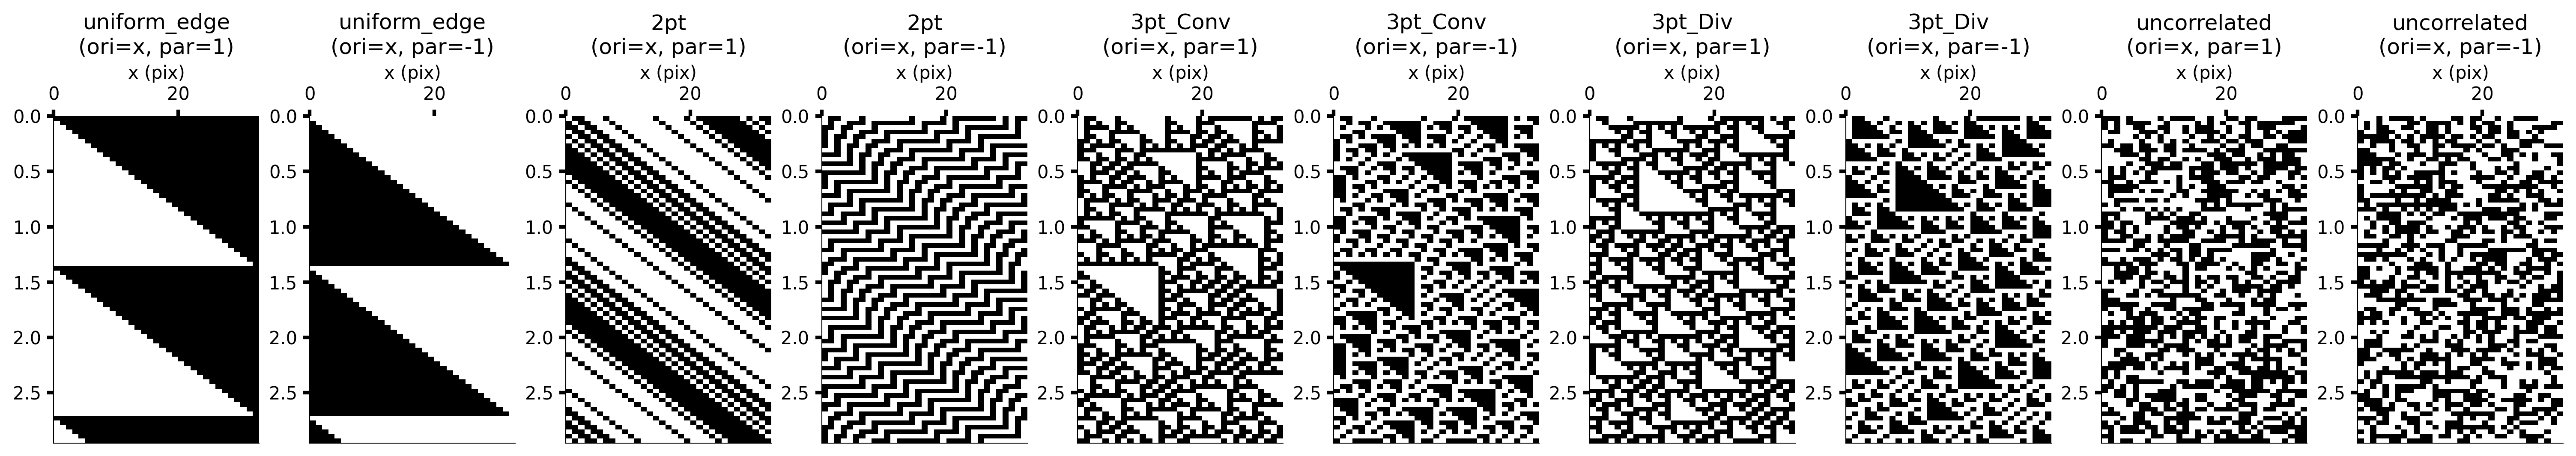

Created movie_input for 20 sequences, shape = torch.Size([20, 300, 1, 721])
Simulation complete! Final responses shape: torch.Size([20, 300, 45669])


In [5]:
fs = 12
tickwidth = 2

responses = []
df_metadata = []

for seed in seeds:
    print(f"-------- Seed: {seed} --------")
    data = CustomStimuli(
        dict(
            extent=15,
            kernel_size=k_size,
            x_resol=x_resol,
            T=T,
            rules=rules,
            directions=["pd", "nd"],
            parities=[1, -1],
            vel=vel,
            seed=seed,
            orientations=['x'],
            subset_idx=[]
        ),
        dt=dt,
        original_framerate=fps,
    )
    n_seqs = data.cartesian_sequences.shape[0]
    t_ax = np.arange(T) / fps
    pd_idx = data.arg_df.query("direction == 'pd'")['sequence_idx'].values
    n_pd = len(pd_idx)

    # Create the figure and axes *once*
    fig, ax = plt.subplots(1, n_pd, figsize=(2.0 * n_pd, 3.5))

    if n_pd == 1:
        ax = [ax] 

    # Loop to draw on each axis
    for j, i in enumerate(pd_idx):
        meta = data.arg_df.loc[i]
        orientation = meta['orientation']
        
        if orientation == 'x':
            # print("Plotting x orientation")
            y_slice = data.cartesian_sequences.shape[2] // 2
            patch = data.cartesian_sequences[i, :, y_slice, :]
            xlabel = 'x'
        else:
            x_slice = data.cartesian_sequences.shape[3] // 2
            patch = data.cartesian_sequences[i, :, :, x_slice]
            xlabel = 'y'

        spatial_res = patch.shape[1]
        
        ax[j].imshow(
            patch,
            origin="upper",
            aspect="auto",
            cmap="gray",
            extent=(0, spatial_res, t_ax[-1], 0)
        )
        
        ax[j].set_xlabel(f"{xlabel} (pix)", fontsize=fs - 2)
        ax[j].xaxis.set_label_position("top")
        ax[j].xaxis.set_ticks_position("top")
        ax[j].tick_params(axis='both', which='major', labelsize=fs - 2, width=tickwidth)
        
        title = f"{meta['rule']}\n(ori={meta['orientation']}, par={meta['parity']})"
        ax[j].set_title(title, fontsize=fs)

    # --- FIX 1: MOVED PLOTTING COMMANDS HERE ---
    # Show the figure *after* the loop is finished
    fig.tight_layout()
    plt.show()
    num_sequences = len(data)
    movie_input = torch.stack([data[i] for i in range(num_sequences)]) #nseqs, T, 1, hexals
    print(f"Created movie_input for {num_sequences} sequences, shape = {movie_input.shape}")

    initial_frame = movie_input[:, 0]
    stationary_state = network.fade_in_state(1.0, data.dt, initial_frame)
    resp = network.simulate(movie_input, data.dt, initial_state=stationary_state).cpu()
    print(f"Simulation complete! Final responses shape: {resp.shape}")

    responses.append(resp)
    meta = data.arg_df.copy()
    meta["seed"] = seed
    meta["T"] = T
    meta["fps"] = fps
    meta["dt"] = dt
    df_metadata.append(meta)

df = pd.concat(df_metadata, ignore_index=True)

In [ ]:
responses = np.array([r.numpy() for r in responses])
print(responses.shape)  # (n_seeds, n_sequences, T, n_neurons)
# filename = f'compute_responses/nw_retrained_gliders_{fps}_fps_{x_resol}_pix_{k_size}_ksize.npz'
filename = f'compute_responses/nw_0_gliders_{fps}_fps_{x_resol}_pix_{k_size}_ksize.npz'

np.savez(filename, responses=responses, df=df.to_dict())
print("Data saved to ", filename)

Data saved to  compute_responses/nw_0_gliders_24_fps_33_pix_1_ksize.npz
